Train: 2015-01-02 to 2024-12-31 (2608 rows)
Test:  2025-01-01 to 2026-06-29 (389 rows)


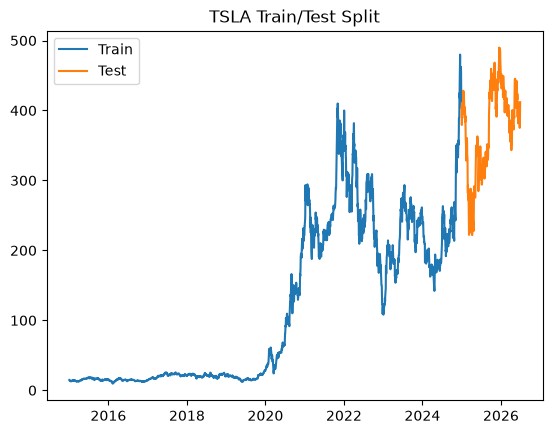

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_combined.csv", index_col=0, parse_dates=True)
tsla = df[df["Ticker"] == "TSLA"][["Close"]].copy()

train = tsla[tsla.index < "2025-01-01"]
test = tsla[tsla.index >= "2025-01-01"]

print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} rows)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} rows)")

fig, ax = plt.subplots()
ax.plot(train.index, train["Close"], label="Train")
ax.plot(test.index, test["Close"], label="Test")
ax.set_title("TSLA Train/Test Split")
ax.legend()
plt.show()

In [2]:
import pmdarima as pm

auto_model = pm.auto_arima(
    train["Close"],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,               # let auto_arima determine differencing via ADF-style tests
    seasonal=False,       # stock prices don't have strong fixed seasonality; SARIMA tested separately below
    trace=True,           # prints each combination tried
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,        # smart search instead of brute-force grid (much faster)
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16873.591, Time=0.47 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.68 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.66 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16873.127, Time=0.37 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16877.541, Time=0.73 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 3.057 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2608
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8435.563
Date:                Wed, 01 Jul 2026   AIC                          16873.127
Time:                        13:51:48   BIC                          16878.993
Sample:                    01-02-2015   HQIC                         16875.252
                         - 12-31-2024                                  

In [3]:
from statsmodels.tsa.arima.model import ARIMA

order = auto_model.order  # (p, d, q) chosen by auto_arima
print(f"Selected order: {order}")

arima_model = ARIMA(train["Close"], order=order)
arima_fit = arima_model.fit()
print(arima_fit.summary())

n_periods = len(test)
forecast_result = arima_fit.get_forecast(steps=n_periods)
arima_forecast = forecast_result.predicted_mean
arima_conf_int = forecast_result.conf_int(alpha=0.05)

arima_forecast.index = test.index
arima_conf_int.index = test.index

Selected order: (0, 1, 0)


c:\Users\pc\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\pc\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\pc\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2608
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -8435.563
Date:                Wed, 01 Jul 2026   AIC                          16873.127
Time:                        13:52:08   BIC                          16878.993
Sample:                    01-02-2015   HQIC                         16875.252
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        37.8492      0.410     92.238      0.000      37.045      38.653
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):             13283.42
Prob(Q):                              0.82   Pr

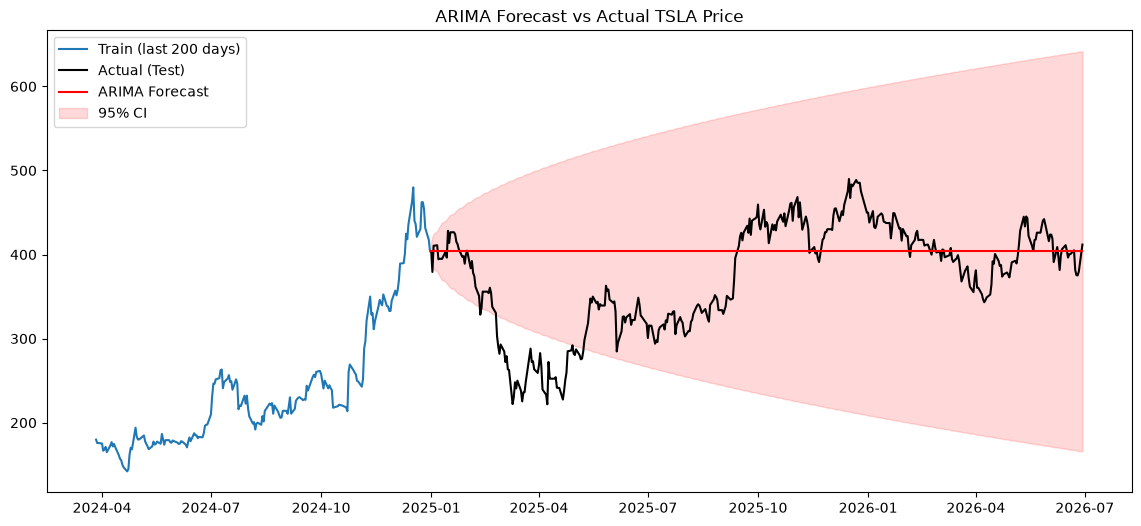

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index[-200:], train["Close"].iloc[-200:], label="Train (last 200 days)")
ax.plot(test.index, test["Close"], label="Actual (Test)", color="black")
ax.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast", color="red")
ax.fill_between(
    arima_conf_int.index,
    arima_conf_int.iloc[:, 0],
    arima_conf_int.iloc[:, 1],
    color="red", alpha=0.15, label="95% CI"
)
ax.set_title("ARIMA Forecast vs Actual TSLA Price")
ax.legend()
plt.show()

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(actual, predicted, label):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"--- {label} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%\n")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

arima_scores = evaluate(test["Close"], arima_forecast, "ARIMA")

--- ARIMA ---
MAE:  54.15
RMSE: 70.20
MAPE: 17.11%



In [6]:
from sklearn.preprocessing import MinMaxScaler

WINDOW = 60  # use last 60 days to predict next day

# Scale using ONLY training data statistics to avoid leaking test info
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train[["Close"]])

# For the test period, we need the WINDOW days immediately preceding it too
full_series = pd.concat([train["Close"], test["Close"]])
full_scaled = scaler.transform(full_series.values.reshape(-1, 1))

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW)

# Test sequences: start WINDOW days before test begins, so first prediction
# corresponds to the first test-set day
test_start_idx = len(train_scaled) - WINDOW
test_scaled_with_lookback = full_scaled[test_start_idx:]
X_test, y_test = create_sequences(test_scaled_with_lookback, WINDOW)

# LSTM expects 3D input: (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (2548, 60, 1)
X_test shape: (389, 60, 1)


c:\Users\pc\portfolio-optimization\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [9]:
import torch
import torch.nn as nn

device = torch.device("cpu")  # low-RAM machine, CPU is fine for this dataset size

# Convert numpy arrays to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc1 = nn.Linear(hidden_size, 25)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(25, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_step = lstm_out[:, -1, :]  # take output from the final time step
        x = self.relu(self.fc1(last_step))
        return self.fc2(x)

model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

LSTMModel(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=50, out_features=25, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=25, out_features=1, bias=True)
)


Epoch 1/20 - loss: 0.030477 - val_loss: 0.009082
Epoch 2/20 - loss: 0.001652 - val_loss: 0.005280
Epoch 3/20 - loss: 0.001223 - val_loss: 0.004113
Epoch 4/20 - loss: 0.001101 - val_loss: 0.003858
Epoch 5/20 - loss: 0.000976 - val_loss: 0.003487
Epoch 6/20 - loss: 0.000892 - val_loss: 0.002748
Epoch 7/20 - loss: 0.000907 - val_loss: 0.002825
Epoch 8/20 - loss: 0.000899 - val_loss: 0.002375
Epoch 9/20 - loss: 0.000727 - val_loss: 0.001989
Epoch 10/20 - loss: 0.000916 - val_loss: 0.002049
Epoch 11/20 - loss: 0.000806 - val_loss: 0.002222
Epoch 12/20 - loss: 0.000646 - val_loss: 0.002346
Epoch 13/20 - loss: 0.000650 - val_loss: 0.001641
Epoch 14/20 - loss: 0.000700 - val_loss: 0.001678
Epoch 15/20 - loss: 0.000595 - val_loss: 0.001623
Epoch 16/20 - loss: 0.000602 - val_loss: 0.001302
Epoch 17/20 - loss: 0.000523 - val_loss: 0.001352
Epoch 18/20 - loss: 0.000492 - val_loss: 0.001286
Epoch 19/20 - loss: 0.000528 - val_loss: 0.001613
Epoch 20/20 - loss: 0.000525 - val_loss: 0.001445


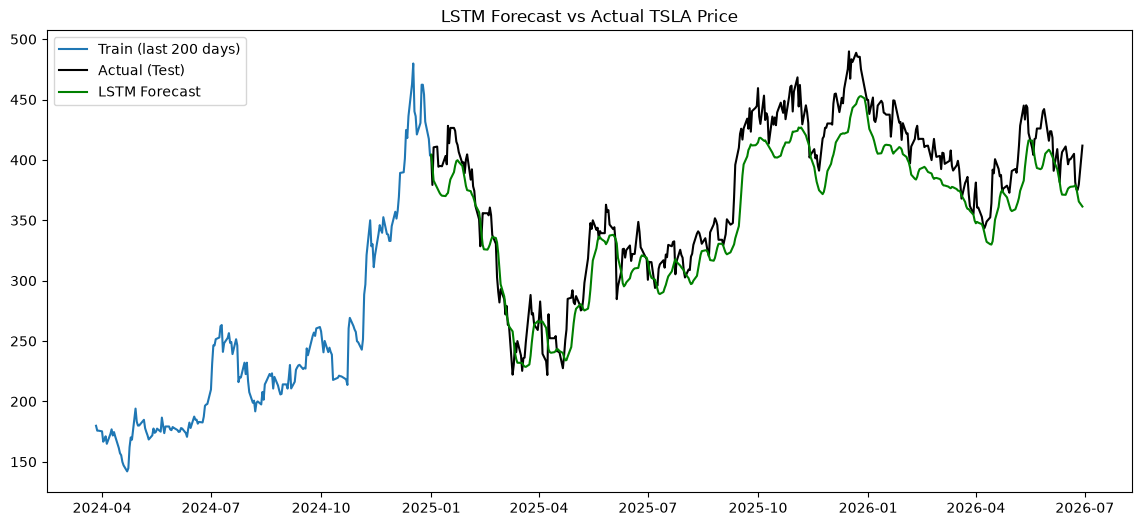

In [10]:
from torch.utils.data import TensorDataset, DataLoader

# Split off 10% for validation, same as Keras validation_split=0.1
val_size = int(0.1 * len(X_train_t))
train_ds = TensorDataset(X_train_t[:-val_size], y_train_t[:-val_size])
val_ds = TensorDataset(X_train_t[-val_size:], y_train_t[-val_size:])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_ds)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_ds)

    print(f"Epoch {epoch+1}/{EPOCHS} - loss: {train_loss:.6f} - val_loss: {val_loss:.6f}")

# Generate predictions on test set
model.eval()
with torch.no_grad():
    lstm_pred_scaled = model(X_test_t).numpy()

lstm_forecast = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_forecast = pd.Series(lstm_forecast, index=test.index)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index[-200:], train["Close"].iloc[-200:], label="Train (last 200 days)")
ax.plot(test.index, test["Close"], label="Actual (Test)", color="black")
ax.plot(lstm_forecast.index, lstm_forecast, label="LSTM Forecast", color="green")
ax.set_title("LSTM Forecast vs Actual TSLA Price")
ax.legend()
plt.show()

In [11]:
lstm_scores = evaluate(test["Close"].values, lstm_forecast.values, "LSTM")

comparison = pd.DataFrame({
    "ARIMA": arima_scores,
    "LSTM": lstm_scores
}).T
comparison

--- LSTM ---
MAE:  21.77
RMSE: 26.04
MAPE: 5.73%



,MAE,RMSE,MAPE
ARIMA,54.151953,70.196786,17.112171
LSTM,21.768400,26.042037,5.728458
